<a href="https://colab.research.google.com/github/nicolejanoff/cb2330-portfolio/blob/main/projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Concentration: 0.0025 µM
Expected response: 0.9999972222299383
Error: 0.004106780925486331
Observed response: 1.0041040031554247

Concentration: 0.008 µM
Expected response: 0.9999715563646189
Error: -0.01256135851257599
Observed response: 0.9874101978520429

Concentration: 0.025 µM
Expected response: 0.9997222993612885
Error: 0.006609935539192408
Observed response: 1.0063322349004808

Concentration: 0.08 µM
Expected response: 0.9971636234710158
Error: -0.006824303555201962
Observed response: 0.9903393199158139

Concentration: 0.25 µM
Expected response: 0.972972972972973
Error: 0.014666041087327521
Observed response: 0.9876390140603005

Concentration: 0.8 µM
Expected response: 0.7785467128027681
Error: -0.001273714258031537
Observed response: 0.7772729985447365

Concentration: 2.53 µM
Expected response: 0.26008854570044737
Error: 0.0004662527438337721
Observed response: 0.26055479844428114

Concentration: 8 µM
Expected response: 0.033962264150943396
Error: -4.497134525851307e-05
Observe

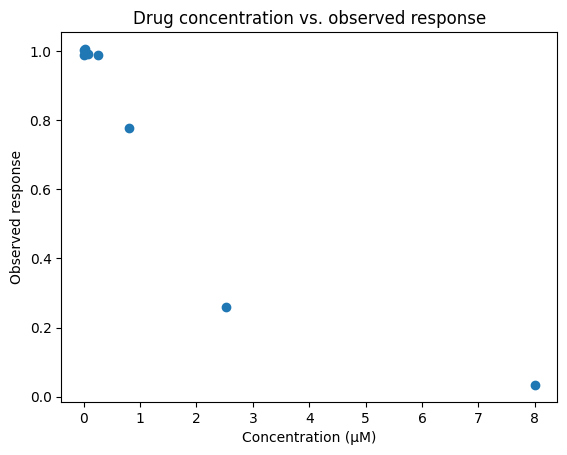

NLL for the chosen parameters: -27.080601885634643
Estimated EC50: 1.5
Estimated h: 2.02
best NLL: -27.116475584494605


In [ ]:
# Project card

## The paper
## The data object
## The random variable chosen
## What the paper does
## The generative model proposed
## Parameters and assumptions
## The forward simulation
## The parameterization/fitting
## What/if the model adds to the paper
## Model limitations/how it breaks


# 1. Introduction

# 2. Generative model

## 2.1 Hill model
import matplotlib.pyplot as plt
import random

# Simplify the Hill model to 2 parameters EC50 and h

def mu(c):
  return 1 /(1 + (c / EC50)**h)


## 2.2 Measurement model
# concentration range: 8 µM to 2.5 nM (8 point dose response assays) according to article, values inbetween were chosen arbitrarily

## 2.3 Assumptions
conc = [0.0025, 0.008, 0.025, 0.08, 0.25, 0.80, 2.53, 8] # µM
cancer_types = {
    "Hud": {"EC50": , "h": },
    "Myelom": {"EC50": , "h": },
    "Benmärg": {"EC50": , "h": }
}

mu_E = 0
sigma_E = 0.01

# 3. Forward simulation
observations = []

for c in conc:
  expected_response = mu(c)
  E = random.gauss(mu_E, sigma_E)
  observation = mu(c) + E
  observations.append(observation)


## 3.1 One observation
  print("Concentration:", c, "µM")
  print("Expected response:", expected_response)
  print("Error:", E)
  print("Observed response:", observation)
  print()


## 3.2 Full dose-response experiment
plt.scatter(conc, observations, label = "Simulated observations")
plt.xlabel("Concentration (µM)")
plt.ylabel("Observed response")
plt.title("Drug concentration vs. observed response")
plt.show()


# 4. Parameter estimation
import math

## 4.1 NLL
def nll(observations, theta):
  """NLL(theta) = - sum log p(y_i | theta)."""
  total = 0.0
  EC50, h = theta

  for i in range(len(observations)):
    x = observations[i]
    c = conc[i]

    mu = 1 /(1 + (c / EC50) ** h)

    log_p = (-0.5 * math.log(2 * math.pi * sigma_E**2) - (x - mu)**2 / (2 * sigma_E ** 2))

    total = total - log_p

  return total

theta = (1.5, 2)
result = nll(observations, theta)
print("NLL for the chosen parameters:", result)

## 4.2 MLE
EC50_hat = None
h_hat = None

best = float("inf")

for a in range(201):
  EC50 = 0.5 + 0.01 * a

  for b in range(251):
    h = 0.5 + 0.01 * b

    score = nll(observations, (EC50, h))

    if score < best:
      best = score
      EC50_hat = EC50
      h_hat = h

print("Estimated EC50:", EC50_hat)
print("Estimated h:", h_hat)
print("best NLL:", best)


# true parameters vs estimated parameters


# 5. Parameter recovery

#Repeat simulation 100/500 times.

#Plot:
#EC50 estimates
#h estimates


# 6. Uncertainty

#Parametric bootstrap.

#95% CI for EC50 and h.


# 7. Model failure

#Increase sigma.

#Show:
#noise -> worse parameter recovery


# 8. Discussion

## Interpretation
## Relation to paper
## Limitations
## What model adds


# 9. Conclusion

First observations:

Hud cell line: 0 concentration: 0.0025 survivors: 100 true EC50: 0.885
Hud cell line: 0 concentration: 0.008 survivors: 100 true EC50: 0.885
Hud cell line: 0 concentration: 0.025 survivors: 100 true EC50: 0.885
Hud cell line: 0 concentration: 0.08 survivors: 97 true EC50: 0.885
Hud cell line: 0 concentration: 0.25 survivors: 91 true EC50: 0.885
Hud cell line: 0 concentration: 0.8 survivors: 59 true EC50: 0.885
Hud cell line: 0 concentration: 2.53 survivors: 12 true EC50: 0.885
Hud cell line: 0 concentration: 8.0 survivors: 1 true EC50: 0.885
Hud cell line: 1 concentration: 0.0025 survivors: 100 true EC50: 0.612
Hud cell line: 1 concentration: 0.008 survivors: 100 true EC50: 0.612


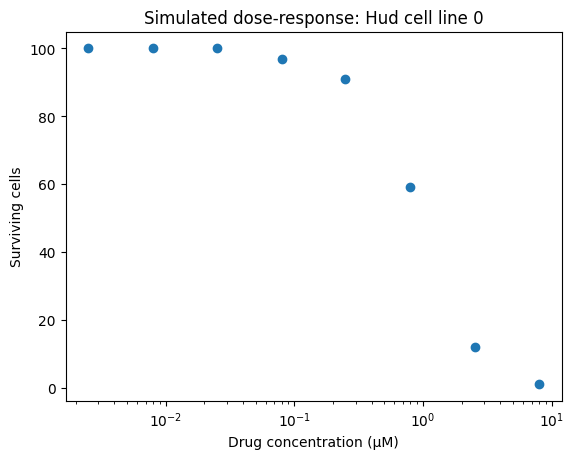

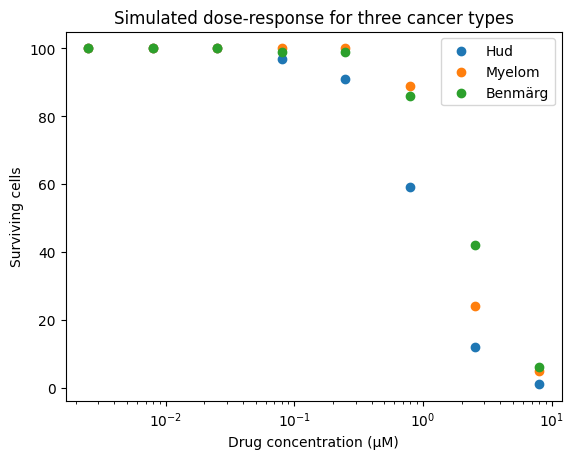


Parameter estimates
--------------------
Hud cell line: 0 | true EC50: 0.885 | estimated EC50: 0.9 | estimated h: 1.81
Hud cell line: 1 | true EC50: 0.612 | estimated EC50: 0.7 | estimated h: 1.94
Hud cell line: 2 | true EC50: 0.879 | estimated EC50: 0.85 | estimated h: 1.91
Hud cell line: 3 | true EC50: 0.886 | estimated EC50: 0.84 | estimated h: 1.78
Hud cell line: 4 | true EC50: 0.67 | estimated EC50: 0.66 | estimated h: 1.89
Hud cell line: 5 | true EC50: 1.621 | estimated EC50: 1.59 | estimated h: 2.0
Hud cell line: 6 | true EC50: 0.609 | estimated EC50: 0.57 | estimated h: 1.98
Hud cell line: 7 | true EC50: 1.153 | estimated EC50: 1.21 | estimated h: 1.85
Hud cell line: 8 | true EC50: 0.695 | estimated EC50: 0.66 | estimated h: 2.0
Hud cell line: 9 | true EC50: 0.887 | estimated EC50: 0.98 | estimated h: 2.0
Myelom cell line: 0 | true EC50: 2.08 | estimated EC50: 1.76 | estimated h: 2.0
Myelom cell line: 1 | true EC50: 1.241 | estimated EC50: 1.36 | estimated h: 2.0
Myelom cell l

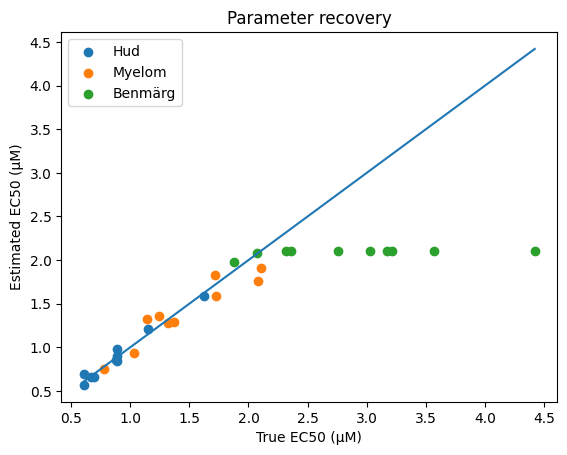


Monte Carlo parameter recovery
-------------------------------
Hud | mean estimated EC50: 1.073
Myelom | mean estimated EC50: 1.657
Benmärg | mean estimated EC50: 2.044


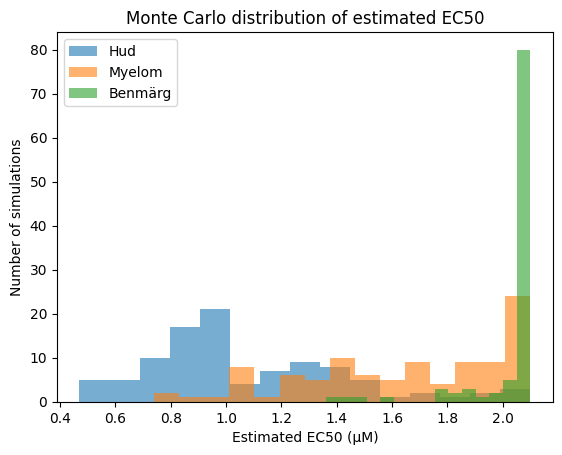

In [ ]:
# ============================================================
# PROJECT: Monte Carlo simulation of drug response
# ============================================================

# The model:
#
# p(c) = 1 / (1 + (c / EC50)^h)
#
# Y ~ Binomial(N0, p(c))
#
# Y = number of surviving cells
# c = drug concentration
# EC50 = concentration giving 50% survival
# h = Hill coefficient
# N0 = initial number of cells
#
# The project has three cancer types.
# Each cancer type has its own distribution of EC50 values.
#
# We:
# 1. Simulate EC50 values for cell lines
# 2. Simulate surviving cells using Monte Carlo
# 3. Plot survival against drug concentration
# 4. Estimate EC50 and h using maximum likelihood
# 5. Compare true and estimated parameters
# 6. Repeat the simulation to investigate parameter recovery
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import random
import math
import matplotlib.pyplot as plt


# ============================================================
# 2. Experimental setup
# ============================================================

# Drug concentrations in µM
conc = [
    0.0025,
    0.008,
    0.025,
    0.08,
    0.25,
    0.80,
    2.53,
    8.0
]

# Initial number of cells
N0 = 100

# Hill coefficient
h_true = 2

# Number of cell lines per cancer type
n_cell_lines = 10


# ============================================================
# 3. Cancer types
# ============================================================

# These are hypothetical values for the simulation.
# They are NOT measurements from the paper.

cancer_types = {

    "Skin cancer": {
        "mean_log_EC50": 0.0,
        "sd_log_EC50": 0.30
    },

    "Myeloma": {
        "mean_log_EC50": 0.5,
        "sd_log_EC50": 0.30
    },

    "Breast cancer": {
        "mean_log_EC50": 1.0,
        "sd_log_EC50": 0.30
    }
}


# ============================================================
# 4. Hill model
# ============================================================

def hill(c, EC50, h):

    return 1 / (1 + (c / EC50) ** h)


# ============================================================
# 5. Monte Carlo simulation of surviving cells
# ============================================================

def simulate_survivors(N0, survival_probability):

    survivors = 0

    for cell in range(N0):

        # Random number between 0 and 1
        r = random.random()

        if r < survival_probability:
            survivors += 1

    return survivors


# ============================================================
# 6. Generate one cell line
# ============================================================

def simulate_cell_line(EC50, h):

    observations = []

    for c in conc:

        # Expected probability of survival
        p = hill(c, EC50, h)

        # Monte Carlo simulation of individual cells
        survivors = simulate_survivors(
            N0,
            p
        )

        observations.append({
            "concentration": c,
            "survivors": survivors
        })

    return observations


# ============================================================
# 7. Generate the complete dataset
# ============================================================

data = []


for cancer_type, parameters in cancer_types.items():

    for cell_number in range(n_cell_lines):

        # Draw EC50 for this cell line
        log_EC50 = random.gauss(
            parameters["mean_log_EC50"],
            parameters["sd_log_EC50"]
        )

        EC50 = math.exp(log_EC50)

        # Simulate dose-response experiment
        observations = simulate_cell_line(
            EC50,
            h_true
        )

        # Store every observation
        for observation in observations:

            data.append({
                "cancer_type": cancer_type,
                "cell_line": cell_number,
                "concentration": observation["concentration"],
                "survivors": observation["survivors"],
                "EC50_true": EC50
            })


# ============================================================
# 8. Inspect simulated data
# ============================================================

print("First observations:")
print()

for row in data[:10]:

    print(
        row["cancer_type"],
        "cell line:", row["cell_line"],
        "concentration:", row["concentration"],
        "survivors:", row["survivors"],
        "true EC50:", round(row["EC50_true"], 3)
    )


# ============================================================
# 9. Plot dose-response for one cell line
# ============================================================

def get_cell_line(data, cancer_type, cell_number):

    observations = []

    for row in data:

        if (
            row["cancer_type"] == cancer_type
            and row["cell_line"] == cell_number
        ):

            observations.append(row)

    return observations


example_data = get_cell_line(
    data,
    "Hud",
    0
)


x = []
y = []

for row in example_data:

    x.append(row["concentration"])
    y.append(row["survivors"])


plt.scatter(x, y)

plt.xscale("log")

plt.xlabel("Drug concentration (µM)")
plt.ylabel("Surviving cells")
plt.title("Simulated dose-response: Hud cell line 0")

plt.show()


# ============================================================
# 10. Plot all three cancer types
# ============================================================

for cancer_type in cancer_types:

    observations = get_cell_line(
        data,
        cancer_type,
        0
    )

    x = []
    y = []

    for row in observations:

        x.append(row["concentration"])
        y.append(row["survivors"])

    plt.scatter(
        x,
        y,
        label=cancer_type
    )


plt.xscale("log")

plt.xlabel("Drug concentration (µM)")
plt.ylabel("Surviving cells")
plt.title("Simulated dose-response for three cancer types")

plt.legend()

plt.show()


# ============================================================
# 11. Negative log likelihood
# ============================================================

def log_binomial_probability(N, Y, p):

    # Avoid log(0)
    if p <= 0:
        p = 1e-10

    if p >= 1:
        p = 1 - 1e-10

    # log of binomial coefficient
    log_combination = (
        math.lgamma(N + 1)
        - math.lgamma(Y + 1)
        - math.lgamma(N - Y + 1)
    )

    return (
        log_combination
        + Y * math.log(p)
        + (N - Y) * math.log(1 - p)
    )


def nll(observations, EC50, h):

    total = 0.0

    for row in observations:

        c = row["concentration"]
        Y = row["survivors"]

        p = hill(
            c,
            EC50,
            h
        )

        log_p = log_binomial_probability(
            N0,
            Y,
            p
        )

        total = total - log_p

    return total


# ============================================================
# 12. Maximum likelihood estimation
# ============================================================

def fit_cell_line(observations):

    best = float("inf")

    EC50_hat = None
    h_hat = None

    # Search over possible EC50 values
    for a in range(201):

        EC50 = 0.1 + 0.01 * a

        # Search over possible Hill coefficients
        for b in range(151):

            h = 0.5 + 0.01 * b

            score = nll(
                observations,
                EC50,
                h
            )

            if score < best:

                best = score
                EC50_hat = EC50
                h_hat = h

    return EC50_hat, h_hat, best


# ============================================================
# 13. Fit all cell lines
# ============================================================

results = []


for cancer_type in cancer_types:

    for cell_number in range(n_cell_lines):

        observations = get_cell_line(
            data,
            cancer_type,
            cell_number
        )

        EC50_hat, h_hat, best_nll = fit_cell_line(
            observations
        )

        EC50_true = observations[0]["EC50_true"]

        results.append({
            "cancer_type": cancer_type,
            "cell_line": cell_number,
            "EC50_true": EC50_true,
            "EC50_hat": EC50_hat,
            "h_hat": h_hat,
            "NLL": best_nll
        })


# ============================================================
# 14. Print parameter estimates
# ============================================================

print()
print("Parameter estimates")
print("--------------------")

for result in results:

    print(
        result["cancer_type"],
        "cell line:", result["cell_line"],
        "| true EC50:",
        round(result["EC50_true"], 3),
        "| estimated EC50:",
        round(result["EC50_hat"], 3),
        "| estimated h:",
        round(result["h_hat"], 2)
    )


# ============================================================
# 15. Plot true vs estimated EC50
# ============================================================

for cancer_type in cancer_types:

    true_values = []
    estimated_values = []

    for result in results:

        if result["cancer_type"] == cancer_type:

            true_values.append(
                result["EC50_true"]
            )

            estimated_values.append(
                result["EC50_hat"]
            )

    plt.scatter(
        true_values,
        estimated_values,
        label=cancer_type
    )


# Reference line y = x
minimum = min(
    [result["EC50_true"] for result in results]
)

maximum = max(
    [result["EC50_true"] for result in results]
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("True EC50 (µM)")
plt.ylabel("Estimated EC50 (µM)")
plt.title("Parameter recovery")

plt.legend()

plt.show()


# ============================================================
# 16. Monte Carlo parameter recovery
# ============================================================

# Number of repeated experiments
n_simulations = 100

recovery = {}


for cancer_type in cancer_types:

    recovery[cancer_type] = []


for simulation in range(n_simulations):

    for cancer_type, parameters in cancer_types.items():

        # Generate one new cell line
        log_EC50 = random.gauss(
            parameters["mean_log_EC50"],
            parameters["sd_log_EC50"]
        )

        EC50_true = math.exp(log_EC50)

        observations = simulate_cell_line(
            EC50_true,
            h_true
        )

        # Add the true EC50 to each observation
        formatted_observations = []

        for observation in observations:

            formatted_observations.append({
                "concentration": observation["concentration"],
                "survivors": observation["survivors"]
            })

        # Estimate parameters
        EC50_hat, h_hat, best_nll = fit_cell_line(
            formatted_observations
        )

        recovery[cancer_type].append({
            "EC50_true": EC50_true,
            "EC50_hat": EC50_hat,
            "h_hat": h_hat
        })


# ============================================================
# 17. Summarize Monte Carlo results
# ============================================================

print()
print("Monte Carlo parameter recovery")
print("-------------------------------")

for cancer_type in cancer_types:

    estimates = []

    for result in recovery[cancer_type]:

        estimates.append(
            result["EC50_hat"]
        )

    mean_estimate = (
        sum(estimates) / len(estimates)
    )

    print(
        cancer_type,
        "| mean estimated EC50:",
        round(mean_estimate, 3)
    )


# ============================================================
# 18. Plot EC50 distributions
# ============================================================

for cancer_type in cancer_types:

    estimates = []

    for result in recovery[cancer_type]:

        estimates.append(
            result["EC50_hat"]
        )

    plt.hist(
        estimates,
        bins=15,
        alpha=0.6,
        label=cancer_type
    )


plt.xlabel("Estimated EC50 (µM)")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo distribution of estimated EC50")

plt.legend()

plt.show()

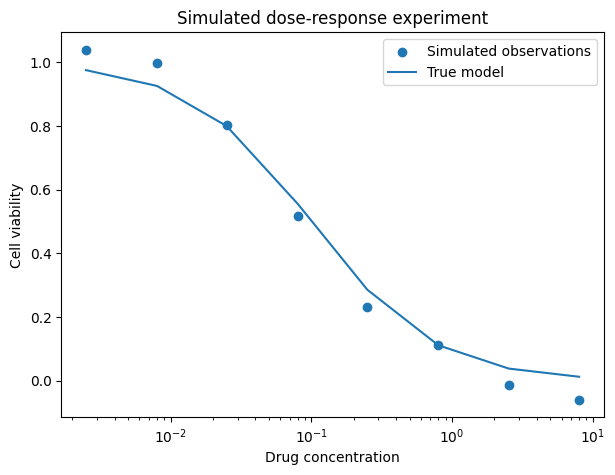

Parameter estimation
--------------------
True EC50:       0.1000
Estimated EC50:  0.0900
Best NLL:         -12.6194


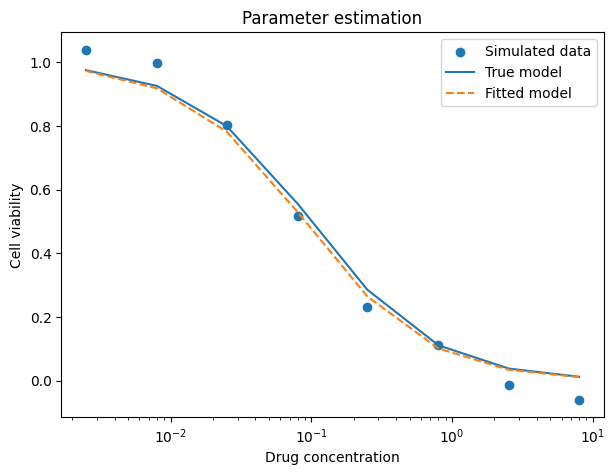

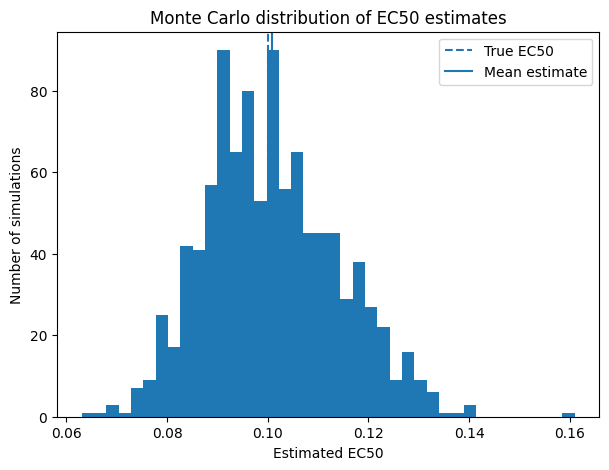


Monte Carlo results
-------------------
True EC50:           0.1000
Mean estimated EC50: 0.1008
Std of estimates:    0.0132
95% range:           [0.0780, 0.1290]


In [3]:
import random
import math
import matplotlib.pyplot as plt



# Generative model
# The Hill equation describes how cell viability changes depending on drug concentration.
# EC50 is the concentration where the predicted viability is 50% of the maximum response.
# In other words, EC50 is the concentration at half-maximal activity of the drug compound

def Hill(concentration, EC50):
    """
    Expected cell viability as a function of drug concentration.
    """
    return 1 / (1 + concentration / EC50)

# Set the random seed so we get the same random results every time we run the code (good to use when debugging)
random.seed(1)

# The true EC50 used to generate our simulated experiment
EC50_true = 0.1

# Standard deviation of the measurement noise
sigma = 0.05

# Drug concentrations used in the simulated experiment
concentrations = [0.0025, 0.008, 0.025, 0.08, 0.25, 0.8, 2.53, 8]  # uM


# Forward simulation

# First calculate the response predicted by the model without any measurement noise
true_response = []

for concentration in concentrations:
    response = Hill(concentration, EC50_true)
    true_response.append(response)

# Simulate what we would actually observe experimentally
# observed response = true response + measurement error
# The measurement error is drawn from a normal distribution with mu = 0
observed_response = []

for i in range(len(concentrations)):
    error = random.gauss(0, sigma)
    response = true_response[i] + error
    observed_response.append(response)


# Plot the simulated experiment

plt.figure(figsize=(7, 5))

plt.scatter(
    concentrations,
    observed_response,
    label="Simulated observations"
)

plt.plot(
    concentrations,
    true_response,
    label="True model"
)

plt.xscale("log")

plt.xlabel("Drug concentration")
plt.ylabel("Cell viability")
plt.title("Simulated dose-response experiment")

plt.legend()
plt.show()


# NLL
# We want to investigate how well a particular EC50 value explains the observed data

def negative_log_likelihood(EC50, concentrations, observations, sigma):
    predicted = []
    for concentration in concentrations:
        response = Hill(concentration, EC50)
        predicted.append(response)

# Calculate the squared difference between the observed and predicted responses
    error_squared = 0

    for i in range(len(observations)):
        residual = observations[i] - predicted[i]
        error_squared = error_squared + residual ** 2


    n = len(observations) # number of observations

# NLL for normally distributed measurement errors
    nll = (0.5 * n * math.log(2 * math.pi * sigma**2) + error_squared / (2 * sigma**2))

    return nll


# Parameter estimation
# We do not know the EC50 of the simulated experiment when "analysing" the data.
# Therefore, we test many possible EC50 values and find the one that gives the lowest NLL

best_EC50 = 0.001
best_nll = float("inf")

EC50 = 0.001

while EC50 <= 1.0:
    nll = negative_log_likelihood(EC50, concentrations, observed_response, sigma)

    if nll < best_nll: # if this EC50 gives a lower NLL than all previous values, save this as the best estimate
        best_nll = nll
        best_EC50 = EC50

    EC50 = EC50 + 0.001 # move to the next possible best EC50 value


EC50_estimated = best_EC50 # the EC50 with the lowest NLL is our estimate


print("Parameter estimation")
print("--------------------")
print(f"True EC50:       {EC50_true:.4f}")
print(f"Estimated EC50:  {EC50_estimated:.4f}")
print(f"Best NLL:         {best_nll:.4f}")


# Plot the fitted model

fitted_response = []
for concentration in concentrations:
    response = Hill(concentration, EC50_estimated)
    fitted_response.append(response)


plt.figure(figsize=(7, 5))
plt.scatter(concentrations, observed_response, label="Simulated data")
plt.plot(concentrations, true_response, label="True model")
plt.plot(concentrations, fitted_response, "--", label="Fitted model")
plt.xscale("log")
plt.xlabel("Drug concentration")
plt.ylabel("Cell viability")
plt.title("Parameter estimation")
plt.legend()
plt.show()

# Monte Carlo
# We repeat the experiment many times to see how much our estimated EC50 changes between simulations
n_simulations = 1000
estimated_EC50s = []


for simulation in range(n_simulations):
    simulated_observations = []

    for concentration in concentrations:
        true_value = Hill(concentration, EC50_true)
        error = random.gauss(0, sigma)
        observed_value = (true_value + error)
        simulated_observations.append(observed_value)

    # Estimate EC50
    best_EC50 = 0.001
    best_nll = float("inf")

    EC50 = 0.001

    while EC50 <= 1.0:
        nll = negative_log_likelihood(EC50, concentrations, simulated_observations, sigma)
        if nll < best_nll:
            best_nll = nll
            best_EC50 = EC50

        EC50 = EC50 + 0.001


    estimated_EC50s.append(best_EC50)


# Distribution (MC)
plt.figure(figsize=(7, 5))
plt.hist(estimated_EC50s, bins=40)
plt.axvline(EC50_true, linestyle="--", label="True EC50")

# Calculate mean manually
mean_estimate = (sum(estimated_EC50s) / len(estimated_EC50s))

plt.axvline(mean_estimate, label="Mean estimate")
plt.xlabel("Estimated EC50")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo distribution of EC50 estimates")
plt.legend()
plt.show()


# Summary

mean_estimate = (sum(estimated_EC50s) / len(estimated_EC50s))


# Standard deviation

squared_differences = []

for estimate in estimated_EC50s:

    difference = (estimate - mean_estimate)

    squared_differences.append(difference ** 2)


variance = (sum(squared_differences) / len(estimated_EC50s))
std_estimate = variance ** 0.5


# 95% range

sorted_estimates = sorted(estimated_EC50s)

lower_index = int(0.025 * len(sorted_estimates))

upper_index = int(0.975 * len(sorted_estimates))

lower = sorted_estimates[lower_index]
upper = sorted_estimates[upper_index]


print("\nMonte Carlo results")
print("-------------------")
print(f"True EC50:           {EC50_true:.4f}")
print(f"Mean estimated EC50: {mean_estimate:.4f}")
print(f"Std of estimates:    {std_estimate:.4f}")
print(f"95% range:           [{lower:.4f}, {upper:.4f}]")


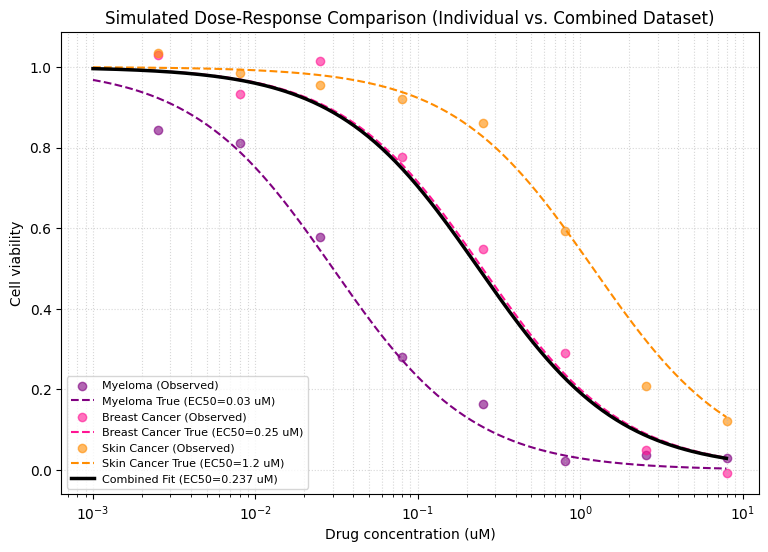

Running Monte Carlo simulations for all 4 variants...

 SUMMARY OF ESTIMATED EC50 PARAMETERS (MONTE CARLO)
Variant                | True EC50  | Mean Est   | Std Dev    | 95% CI              
--------------------------------------------------------------------------------
Myeloma                | 0.030      | 0.0301     | 0.0030     | [0.0250, 0.0370]
Breast Cancer          | 0.250      | 0.2526     | 0.0330     | [0.1990, 0.3230]
Skin Cancer            | 1.200      | 1.2245     | 0.1950     | [0.8570, 1.6250]
Combined (All Types)   | N/A        | 0.2117     | 0.0197     | [0.1750, 0.2530]


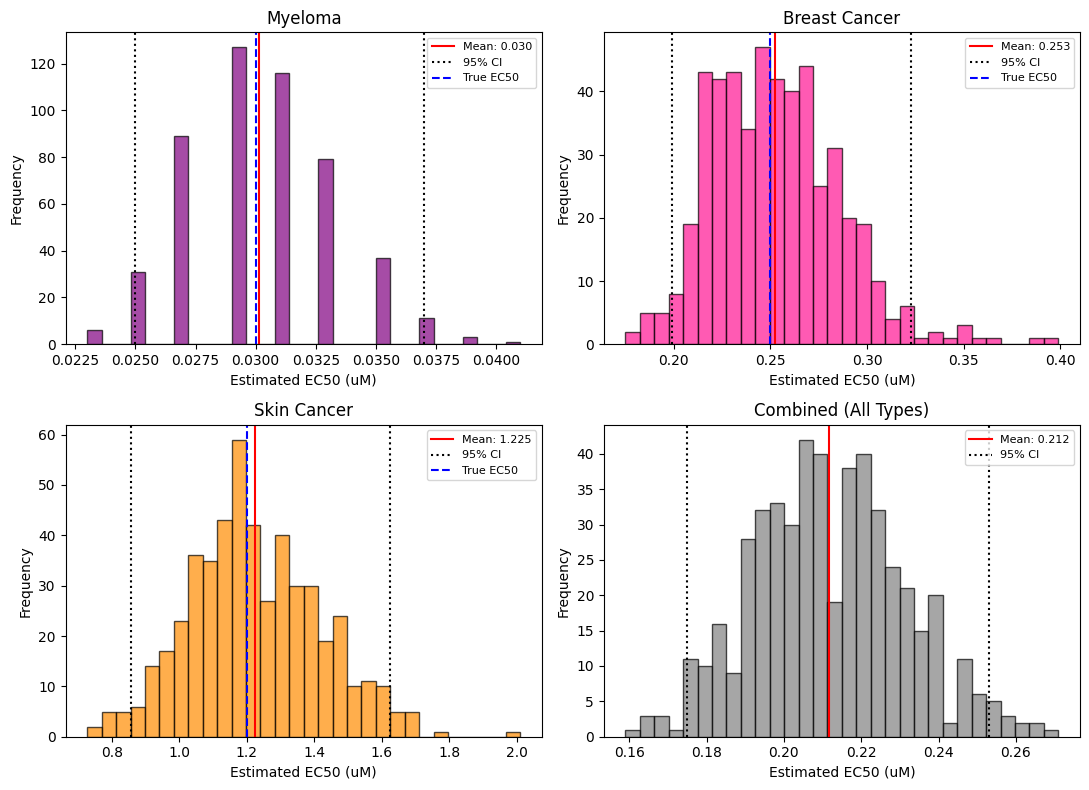

In [ ]:
import random
import math
import matplotlib.pyplot as plt

# Sätt seed för reproducerbarhet
random.seed(40)

# ============================================================
# 1. GENERATIVE MODEL & LOG-LIKELIHOOD (REN PYTHON)
# ============================================================

def hill_model(concentration, ec50):
    """
    Klassisk Hill-modell för celldöd/överlevnad.
    """
    return 1.0 / (1.0 + concentration / ec50)

def negative_log_likelihood(ec50, concentrations, observations, sigma):
    """
    Negative Log-Likelihood för Gaussiskt mätbrus.
    """
    predicted = []
    for c in concentrations:
        predicted.append(hill_model(c, ec50))

    squared_error = 0.0
    for i in range(len(observations)):
        residual = observations[i] - predicted[i]
        squared_error += residual**2

    n = len(observations)
    nll = (0.5 * n * math.log(2 * math.pi * sigma**2)) + (squared_error / (2 * sigma**2))
    return nll

def fit_ec50(concentrations, observations, sigma):
    """
    Söker upp det EC50 som minimerar NLL med grid-sökning.
    """
    best_ec50 = 0.001
    best_nll = float("inf")

    ec50 = 0.001
    while ec50 <= 3.0:
        nll = negative_log_likelihood(ec50, concentrations, observations, sigma)
        if nll < best_nll:
            best_nll = nll
            best_ec50 = ec50
        ec50 += 0.002

    return best_ec50

# ============================================================
# 2. CANCER TYPE PROFILES & SIMULATION SETTINGS
# ============================================================

concentrations = [0.0025, 0.008, 0.025, 0.08, 0.25, 0.8, 2.53, 8.0]

# Definiera egenskaper för de 3 enskilda cancertyperna
cancer_types = {
    "Myeloma": {"ec50_true": 0.03, "sigma": 0.04, "color": "purple"},
    "Breast Cancer": {"ec50_true": 0.25, "sigma": 0.05, "color": "deeppink"},
    "Skin Cancer": {"ec50_true": 1.20, "sigma": 0.06, "color": "darkorange"}
}

# ============================================================
# 3. FORWARD SIMULATION (SINGLE EXPERIMENTS)
# ============================================================

simulated_data = {}

for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    true_resp = []
    obs_resp = []

    for c in concentrations:
        val = hill_model(c, ec50_true)
        true_resp.append(val)

        # Add Gaussiskt mätbrus
        error = random.gauss(0, sig)
        obs_resp.append(val + error)

    simulated_data[c_type] = {
        "true_response": true_resp,
        "observed_response": obs_resp
    }

# Dataset för Variant 4: Kombinerat dataset för alla 3 cancertyper
combined_concentrations = []
combined_observations = []

for c_type in cancer_types:
    combined_concentrations.extend(concentrations)
    combined_observations.extend(simulated_data[c_type]["observed_response"])

# Genomsnittligt sigma för kombinerat dataset
combined_sigma = sum(props["sigma"] for props in cancer_types.values()) / len(cancer_types)

# Anpassa en gemensam Hill-kurva till det kombinerade datasetet
combined_fitted_ec50 = fit_ec50(combined_concentrations, combined_observations, combined_sigma)

# ============================================================
# 4. PLOT SIMULATED EXPERIMENTS (INKLUSIVE KOMBINERAT DATASET)
# ============================================================

plt.figure(figsize=(9, 6))

# Generera en jämn koncentrationsserie för släta kurvor
fine_concentrations = []
curr = 0.001
while curr <= 8.0:
    fine_concentrations.append(curr)
    curr *= 1.05

# 1. Plotta de 3 enskilda cancertyperna
for c_type, props in cancer_types.items():
    # Observerade punkter
    plt.scatter(
        concentrations,
        simulated_data[c_type]["observed_response"],
        color=props["color"],
        alpha=0.6,
        label=f"{c_type} (Observed)"
    )

    # Teoretiska sanningskurvor
    fine_curve = [hill_model(c, props["ec50_true"]) for c in fine_concentrations]
    plt.plot(
        fine_concentrations,
        fine_curve,
        color=props["color"],
        linestyle="--",
        label=f"{c_type} True (EC50={props['ec50_true']} uM)"
    )

# 2. Plotta det Kombinerade Datasetet och dess anpassade kurva
combined_fitted_curve = [hill_model(c, combined_fitted_ec50) for c in fine_concentrations]
plt.plot(
    fine_concentrations,
    combined_fitted_curve,
    color="black",
    linewidth=2.5,
    linestyle="-",
    label=f"Combined Fit (EC50={combined_fitted_ec50:.3f} uM)"
)

plt.xscale("log")
plt.xlabel("Drug concentration (uM)")
plt.ylabel("Cell viability")
plt.title("Simulated Dose-Response Comparison (Individual vs. Combined Dataset)")
plt.legend(fontsize=8, loc="lower left")
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()

# ============================================================
# 5. MONTE CARLO SIMULATION (ALL 4 VARIANTS)
# ============================================================

n_simulations = 500

mc_results = {
    "Myeloma": [],
    "Breast Cancer": [],
    "Skin Cancer": [],
    "Combined (All Types)": []
}

print("Running Monte Carlo simulations for all 4 variants...")

# A. Monte Carlo för de 3 enskilda cancertyperna
for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    for sim in range(n_simulations):
        sim_obs = []
        for c in concentrations:
            true_val = hill_model(c, ec50_true)
            noisy_val = true_val + random.gauss(0, sig)
            sim_obs.append(noisy_val)

        est_ec50 = fit_ec50(concentrations, sim_obs, sig)
        mc_results[c_type].append(est_ec50)

# B. Monte Carlo för Variant 4: Kombinerat dataset
for sim in range(n_simulations):
    pooled_obs = []
    for c_type, props in cancer_types.items():
        ec50_true = props["ec50_true"]
        sig = props["sigma"]
        for c in concentrations:
            true_val = hill_model(c, ec50_true)
            noisy_val = true_val + random.gauss(0, sig)
            pooled_obs.append(noisy_val)

    est_comb_ec50 = fit_ec50(combined_concentrations, pooled_obs, combined_sigma)
    mc_results["Combined (All Types)"].append(est_comb_ec50)

# ============================================================
# 6. CALCULATE STATISTICS & PLOT HISTOGRAMS (REN PYTHON)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

all_variants = ["Myeloma", "Breast Cancer", "Skin Cancer", "Combined (All Types)"]
colors = ["purple", "deeppink", "darkorange", "gray"]

print("\n=============================================================")
print(" SUMMARY OF ESTIMATED EC50 PARAMETERS (MONTE CARLO)")
print("=============================================================")
print(f"{'Variant':<22} | {'True EC50':<10} | {'Mean Est':<10} | {'Std Dev':<10} | {'95% CI':<20}")
print("-" * 80)

for idx, variant in enumerate(all_variants):
    estimates = mc_results[variant]

    # 1. Medelvärde
    mean_est = sum(estimates) / len(estimates)

    # 2. Standardavvikelse
    sq_diffs = [(x - mean_est)**2 for x in estimates]
    variance = sum(sq_diffs) / len(estimates)
    std_est = math.sqrt(variance)

    # 3. 95% konfidensintervall (Percentiler)
    sorted_est = sorted(estimates)
    lower_idx = int(0.025 * len(sorted_est))
    upper_idx = int(0.975 * len(sorted_est))
    lower_ci = sorted_est[lower_idx]
    upper_ci = sorted_est[upper_idx]

    true_str = f"{cancer_types[variant]['ec50_true']:.3f}" if variant in cancer_types else "N/A"
    print(f"{variant:<22} | {true_str:<10} | {mean_est:<10.4f} | {std_est:<10.4f} | [{lower_ci:.4f}, {upper_ci:.4f}]")

    # Plotta histogram
    ax = axes_list[idx]
    ax.hist(estimates, bins=30, color=colors[idx], alpha=0.7, edgecolor="black")
    ax.axvline(mean_est, color="red", linestyle="-", label=f"Mean: {mean_est:.3f}")
    ax.axvline(lower_ci, color="black", linestyle=":", label="95% CI")
    ax.axvline(upper_ci, color="black", linestyle=":")

    if variant in cancer_types:
        ax.axvline(cancer_types[variant]["ec50_true"], color="blue", linestyle="--", label="True EC50")

    ax.set_title(variant)
    ax.set_xlabel("Estimated EC50 (uM)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

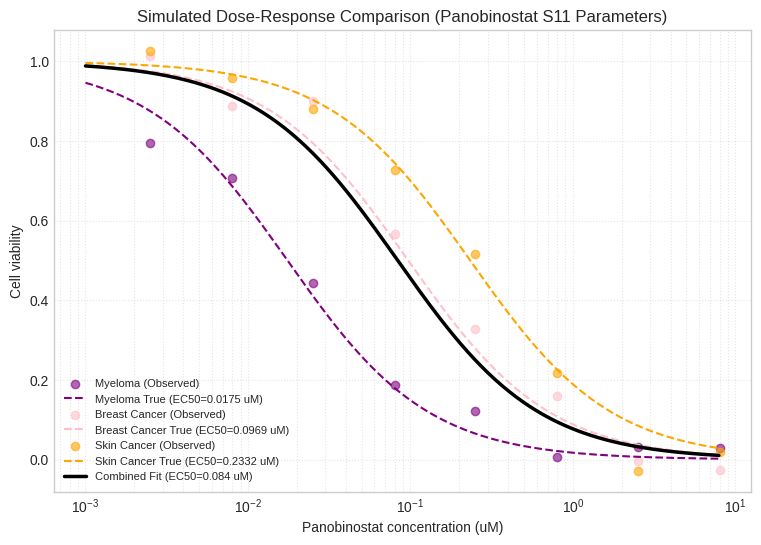


 SUMMARY OF ESTIMATED EC50 PARAMETERS (MONTE CARLO)
Variant                | True EC50  | Mean Est   | Std Dev    | 95% CI              
--------------------------------------------------------------------------------
Myeloma                | 0.0175     | 0.0175     | 0.0018     | [0.0145, 0.0210]
Breast Cancer          | 0.0969     | 0.0982     | 0.0125     | [0.0770, 0.1230]
Skin Cancer            | 0.2332     | 0.2385     | 0.0390     | [0.1680, 0.3300]
Combined (All Types)   | N/A        | 0.0745     | 0.0065     | [0.0625, 0.0870]


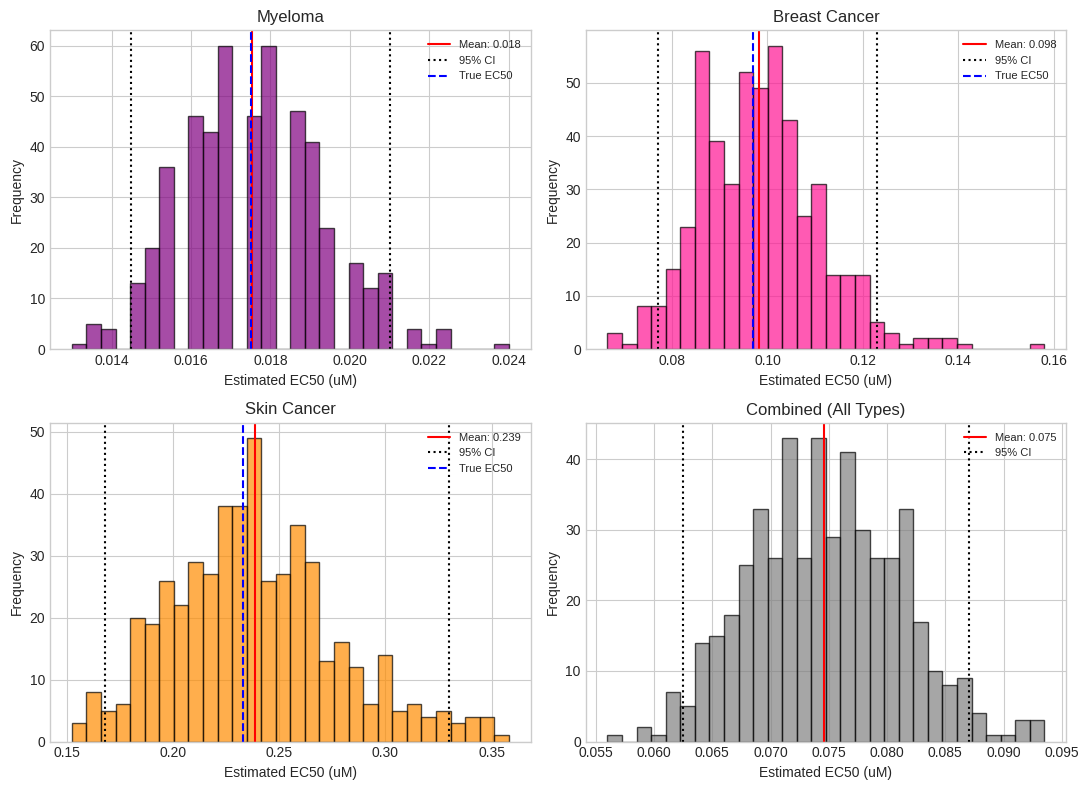

In [ ]:
import random
import math
import matplotlib.pyplot as plt

# Choosing a seed for the Monte Carlo to be able to reproduce the simulation
random.seed(40)

# Generative modell

# Simplification of the Hill equation is used to modell cell death/survival
def hill_model(concentration, ec50):
    return 1.0 / (1.0 + concentration / ec50)

# negative log likelihoop is used to
def negative_log_likelihood(ec50, concentrations, observations, sigma):
    """
    Negative Log-Likelihood för Gaussiskt mätbrus.
    """
    # calculated what EC50 should be acc. to Hill eq. for a given c and adds it to the list
    predicted = []
    for c in concentrations:
        predicted.append(hill_model(c, ec50))

    # calculated the squared error (observation - modell)^2
    squared_error = 0.0
    for i in range(len(observations)):
        residual = observations[i] - predicted[i]
        squared_error += residual**2

    # calculates the nll given the observations
    n = len(observations)
    nll = (0.5 * n * math.log(2 * math.pi * sigma**2)) + (squared_error / (2 * sigma**2))
    return nll

# uses adaptive step to determine the smallest nll
# 2. Numerisk derivata (räknar ut lutningen på NLL vid ett visst ec50)
def slope_at(score, theta, h=0.0001):
    return (score(theta + h) - score(theta - h)) / (2 * h)

def descend_adaptive(score, theta, alpha, h=0.0001, tol=1e-3, max_steps=1000):
    """
    Söker minimat för NLL med adaptiv steglängd.
    theta = startgissning på EC50
    alpha = initial inlärningshastighet/steglängd
    """
    path = [theta]
    for step in range(max_steps):
        slope = slope_at(score, theta, h)
        if abs(slope) < tol:
            return path

        # Beräkna nästa testade theta
        theta_try = theta - alpha * slope

        # Förhindra att EC50 blir negativt eller noll
        if theta_try <= 0:
            alpha = alpha * 0.5
            continue

        # Om NLL stiger (sämre passning) -> halvera alpha
        if score(theta_try) > score(theta):
            alpha = alpha * 0.5
        # Om NLL sjunker (bättre passning) -> acceptera nytt theta och öka alpha med 1.2
        else:
            theta = theta_try
            alpha = alpha * 1.2

        path.append(theta)
    return path

def fit_ec50_adaptive(concentrations, observations, sigma, initial_ec50=0.5):
    """
    Använder adaptiv gradient descent för att snabbt hitta bäst EC50.
    """
    # Skapa en score-funktion (NLL) som bara beror på ec50
    score_func = lambda ec50: negative_log_likelihood(ec50, concentrations, observations, sigma)

    # Kör den adaptiva sökningen
    path = descend_adaptive(score_func, theta=initial_ec50, alpha=0.001)

    # Returnera det sista (och bästa) EC50-värdet
    return path[-1]


# Concentrations for panobinostat presented in table S11 in the report
concentrations = [0.0025, 0.0080, 0.0250, 0.0800, 0.2500, 0.8000, 2.5300, 8.0000]

# Empiriska genomsnittliga EC50-värden (uM) för Panobinostat från Tabell S11
cancer_types = {
    "Myeloma": {"ec50_true": 0.0175, "sigma": 0.04, "color": "purple"},
    "Breast Cancer": {"ec50_true": 0.0969, "sigma": 0.05, "color": "pink"},
    "Skin Cancer": {"ec50_true": 0.2332, "sigma": 0.06, "color": "orange"}
}

# 3. FORWARD SIMULATION (simulation where one single experiment is carried out)


simulated_data = {}

for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    true_resp = []
    obs_resp = []

    for c in concentrations:
        val = hill_model(c, ec50_true)
        true_resp.append(val)

        # Lägg till Gaussiskt (normalfördelat) mätbrus
        error = random.gauss(0, sig)
        obs_resp.append(val + error)

    simulated_data[c_type] = {
        "true_response": true_resp,
        "observed_response": obs_resp
    }

# Dataset för Variant 4: Kombinerat dataset för alla 3 cancertyper
combined_concentrations = []
combined_observations = []

for c_type in cancer_types:
    combined_concentrations.extend(concentrations)
    combined_observations.extend(simulated_data[c_type]["observed_response"])

# Genomsnittligt sigma för kombinerat dataset
combined_sigma = sum(props["sigma"] for props in cancer_types.values()) / len(cancer_types)

# Anpassa en gemensam Hill-kurva till det kombinerade datasetet
combined_fitted_ec50 = fit_ec50(combined_concentrations, combined_observations, combined_sigma)

# 4. PLOT SIMULATED EXPERIMENTS (INDIVIDUAL VS. COMBINED)


plt.figure(figsize=(9, 6))

fine_concentrations = []
curr = 0.001
while curr <= 8.0:
    fine_concentrations.append(curr)
    curr *= 1.05

# 1. Plotta de 3 enskilda cancertyperna
for c_type, props in cancer_types.items():
    plt.scatter(
        concentrations,
        simulated_data[c_type]["observed_response"],
        color=props["color"],
        alpha=0.6,
        label=f"{c_type} (Observed)"
    )

    fine_curve = [hill_model(c, props["ec50_true"]) for c in fine_concentrations]
    plt.plot(
        fine_concentrations,
        fine_curve,
        color=props["color"],
        linestyle="--",
        label=f"{c_type} True (EC50={props['ec50_true']} uM)"
    )

# 2. Plotta det Kombinerade Datasetet och dess anpassade kurva
combined_fitted_curve = [hill_model(c, combined_fitted_ec50) for c in fine_concentrations]
plt.plot(
    fine_concentrations,
    combined_fitted_curve,
    color="black",
    linewidth=2.5,
    linestyle="-",
    label=f"Combined Fit (EC50={combined_fitted_ec50:.3f} uM)"
)

plt.xscale("log")
plt.xlabel("Panobinostat concentration (uM)")
plt.ylabel("Cell viability")
plt.title("Simulated Dose-Response Comparison (Panobinostat S11 Parameters)")
plt.legend(fontsize=8, loc="lower left")
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()

# 5. MONTE CARLO SIMULATION (ALL 4 VARIANTS)

n_simulations = 500

mc_results = {
    "Myeloma": [],
    "Breast Cancer": [],
    "Skin Cancer": [],
    "Combined (All Types)": []
}

# A. Monte Carlo för de 3 enskilda cancertyperna
for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    for sim in range(n_simulations):
        sim_obs = []
        for c in concentrations:
            true_val = hill_model(c, ec50_true)
            noisy_val = true_val + random.gauss(0, sig)
            sim_obs.append(noisy_val)

        est_ec50 = fit_ec50(concentrations, sim_obs, sig)
        mc_results[c_type].append(est_ec50)

# B. Monte Carlo för Variant 4: Kombinerat dataset
for sim in range(n_simulations):
    pooled_obs = []
    for c_type, props in cancer_types.items():
        ec50_true = props["ec50_true"]
        sig = props["sigma"]
        for c in concentrations:
            true_val = hill_model(c, ec50_true)
            noisy_val = true_val + random.gauss(0, sig)
            pooled_obs.append(noisy_val)

    est_comb_ec50 = fit_ec50(combined_concentrations, pooled_obs, combined_sigma)
    mc_results["Combined (All Types)"].append(est_comb_ec50)

# ============================================================
# 6. CALCULATE STATISTICS & PLOT HISTOGRAMS (REN PYTHON)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

all_variants = ["Myeloma", "Breast Cancer", "Skin Cancer", "Combined (All Types)"]
colors = ["purple", "deeppink", "darkorange", "gray"]

print("\n=============================================================")
print(" SUMMARY OF ESTIMATED EC50 PARAMETERS (MONTE CARLO)")
print("=============================================================")
print(f"{'Variant':<22} | {'True EC50':<10} | {'Mean Est':<10} | {'Std Dev':<10} | {'95% CI':<20}")
print("-" * 80)

for idx, variant in enumerate(all_variants):
    estimates = mc_results[variant]

    # 1. Medelvärde
    mean_est = sum(estimates) / len(estimates)

    # 2. Standardavvikelse
    sq_diffs = [(x - mean_est)**2 for x in estimates]
    variance = sum(sq_diffs) / len(estimates)
    std_est = math.sqrt(variance)

    # 3. 95% konfidensintervall (Percentiler)
    sorted_est = sorted(estimates)
    lower_idx = int(0.025 * len(sorted_est))
    upper_idx = int(0.975 * len(sorted_est))
    lower_ci = sorted_est[lower_idx]
    upper_ci = sorted_est[upper_idx]

    true_str = f"{cancer_types[variant]['ec50_true']:.4f}" if variant in cancer_types else "N/A"
    print(f"{variant:<22} | {true_str:<10} | {mean_est:<10.4f} | {std_est:<10.4f} | [{lower_ci:.4f}, {upper_ci:.4f}]")

    # Plotta histogram
    ax = axes_list[idx]
    ax.hist(estimates, bins=30, color=colors[idx], alpha=0.7, edgecolor="black")
    ax.axvline(mean_est, color="red", linestyle="-", label=f"Mean: {mean_est:.3f}")
    ax.axvline(lower_ci, color="black", linestyle=":", label="95% CI")
    ax.axvline(upper_ci, color="black", linestyle=":")

    if variant in cancer_types:
        ax.axvline(cancer_types[variant]["ec50_true"], color="blue", linestyle="--", label="True EC50")

    ax.set_title(variant)
    ax.set_xlabel("Estimated EC50 (uM)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

import random
import math
import matplotlib.pyplot as plt

# Choosing a seed for reproducibility
random.seed(40)

# ============================================================
# 1. GENERATIVE MODEL & LIKELIHOOD
# ============================================================

def hill_model(concentration, ec50):
    return 1.0 / (1.0 + concentration / ec50)

def negative_log_likelihood(ec50, concentrations, observations, sigma):
    predicted = [hill_model(c, ec50) for c in concentrations]
    squared_error = sum((obs - pred)**2 for obs, pred in zip(observations, predicted))
    n = len(observations)
    return (0.5 * n * math.log(2 * math.pi * sigma**2)) + (squared_error / (2 * sigma**2))

# ============================================================
# 2. BAYESIAN THINKING (PRIOR, POSTERIOR & MCMC SAMPLER)
# ============================================================

def log_prior(ec50):
    """
    Bayesiansk Prior: Inkluderar biologisk förhandskunskap.
    EC50 måste vara positivt och högst troligt under 3.0 uM.
    """
    if ec50 <= 0 or ec50 > 3.0:
        return -float("inf")
    # Log-Normal prior centrerad kring 0.05 uM
    return -math.log(ec50) - ((math.log(ec50) - math.log(0.05))**2 / (2 * 1.0**2))

def log_posterior(ec50, concentrations, observations, sigma):
    """
    Posterior = Log-Prior + Log-Likelihood (vilket är -NLL)
    """
    lp = log_prior(ec50)
    if math.isinf(lp):
        return -float("inf")
    log_ll = -negative_log_likelihood(ec50, concentrations, observations, sigma)
    return lp + log_ll

def sample_bayes_mcmc(concentrations, observations, sigma, n_samples=3000, initial_ec50=0.1):
    """
    Metropolis-Hastings MCMC: Genererar sampel från posteriorfördelningen.
    """
    current_ec50 = initial_ec50
    samples = []

    for _ in range(n_samples):
        # Föreslå ett nytt EC50 i närheten med Gaussiskt kliv
        proposal = current_ec50 + random.gauss(0, 0.003)

        # Beräkna acceptanssannolikhet
        log_alpha = log_posterior(proposal, concentrations, observations, sigma) - log_posterior(current_ec50, concentrations, observations, sigma)

        if math.log(random.random()) < log_alpha:
            current_ec50 = proposal

        samples.append(current_ec50)

    # Ta bort "burn-in" (de första 1000 samplen innan kedjan stabiliserats)
    return samples[1000:]

# ============================================================
# 3. ADAPTIVE GRADIENT DESCENT OPTIMIZER (FREQUENTIST / MLE)
# ============================================================

def slope_at(score, theta, h=0.0001):
    return (score(theta + h) - score(theta - h)) / (2 * h)

def descend_adaptive(score, theta, alpha, h=0.0001, tol=1e-3, max_steps=1000):
    path = [theta]
    for step in range(max_steps):
        slope = slope_at(score, theta, h)
        if abs(slope) < tol:
            return path

        theta_try = theta - alpha * slope
        if theta_try <= 0:
            alpha = alpha * 0.5
            continue

        if score(theta_try) > score(theta):
            alpha = alpha * 0.5
        else:
            theta = theta_try
            alpha = alpha * 1.2

        path.append(theta)
    return path

def fit_ec50_adaptive(concentrations, observations, sigma, initial_ec50=0.5):
    score_func = lambda ec50: negative_log_likelihood(ec50, concentrations, observations, sigma)
    path = descend_adaptive(score_func, theta=initial_ec50, alpha=0.001)
    return path[-1]

# ============================================================
# DATA & PARAMETERS (Panobinostat S11)
# ============================================================

concentrations = [0.0025, 0.0080, 0.0250, 0.0800, 0.2500, 0.8000, 2.5300, 8.0000]

cancer_types = {
    "Myeloma": {"ec50_true": 0.0175, "sigma": 0.04, "color": "purple"},
    "Breast Cancer": {"ec50_true": 0.0969, "sigma": 0.05, "color": "pink"},
    "Skin Cancer": {"ec50_true": 0.2332, "sigma": 0.06, "color": "orange"}
}

# ============================================================
# 4. SINGLE EXPERIMENT SIMULATION
# ============================================================

simulated_data = {}
for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    obs_resp = [hill_model(c, ec50_true) + random.gauss(0, sig) for c in concentrations]
    simulated_data[c_type] = {"observed_response": obs_resp}

# Dataset för Variant 4: Kombinerat dataset
combined_concentrations = []
combined_observations = []
for c_type in cancer_types:
    combined_concentrations.extend(concentrations)
    combined_observations.extend(simulated_data[c_type]["observed_response"])

combined_sigma = sum(props["sigma"] for props in cancer_types.values()) / len(cancer_types)
combined_fitted_ec50 = fit_ec50_adaptive(combined_concentrations, combined_observations, combined_sigma)

# ============================================================
# 5. BAYESIAN POSTERIOR ANALYSIS ON SINGLE EXPERIMENTS
# ============================================================

print("\n=============================================================")
print(" BAYESIAN POSTERIOR ESTIMATES (SINGLE EXPERIMENT)")
print("=============================================================")
print(f"{'Cancer Type':<18} | {'True EC50':<10} | {'Posterior Mean':<14} | {'95% Credible Interval':<22}")
print("-" * 72)

bayes_samples = {}
for c_type, props in cancer_types.items():
    obs = simulated_data[c_type]["observed_response"]
    samples = sample_bayes_mcmc(concentrations, obs, props["sigma"], initial_ec50=props["ec50_true"])
    bayes_samples[c_type] = samples

    mean_p = sum(samples) / len(samples)
    sorted_s = sorted(samples)
    ci_low = sorted_s[int(0.025 * len(sorted_s))]
    ci_high = sorted_s[int(0.975 * len(sorted_s))]

    print(f"{c_type:<18} | {props['ec50_true']:<10.4f} | {mean_p:<14.4f} | [{ci_low:.4f}, {ci_high:.4f}]")

# ============================================================
# 6. MONTE CARLO SIMULATION (FREQUENTIST COMPARISON)
# ============================================================

n_simulations = 500
mc_results = {c: [] for c in cancer_types}
mc_results["Combined (All Types)"] = []

for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]
    for _ in range(n_simulations):
        sim_obs = [hill_model(c, ec50_true) + random.gauss(0, sig) for c in concentrations]
        est = fit_ec50_adaptive(concentrations, sim_obs, sig, initial_ec50=ec50_true)
        mc_results[c_type].append(est)

for _ in range(n_simulations):
    pooled_obs = []
    for c_type, props in cancer_types.items():
        pooled_obs.extend([hill_model(c, props["ec50_true"]) + random.gauss(0, props["sigma"]) for c in concentrations])
    est_c = fit_ec50_adaptive(combined_concentrations, pooled_obs, combined_sigma, initial_ec50=0.1)
    mc_results["Combined (All Types)"].append(est_c)

# ============================================================
# 7. VISUALIZE BAYESIAN POSTERIOR VS MONTE CARLO
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

all_variants = ["Myeloma", "Breast Cancer", "Skin Cancer", "Combined (All Types)"]
colors = ["purple", "deeppink", "darkorange", "gray"]

for idx, variant in enumerate(all_variants):
    ax = axes_list[idx]

    # Plotta Monte Carlo (Frequentist)
    ax.hist(mc_results[variant], bins=30, color=colors[idx], alpha=0.5, density=True, label="Monte Carlo (MLE)")

    # Om det är en av de enskilda cancertyperna, lägg över den Bayesianska posterior-fördelningen
    if variant in bayes_samples:
        ax.hist(bayes_samples[variant], bins=30, color="cyan", alpha=0.5, density=True, label="Bayesian Posterior")
        ax.axvline(cancer_types[variant]["ec50_true"], color="blue", linestyle="--", label="True EC50")

    ax.set_title(variant)
    ax.set_xlabel("EC50 (uM)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


 BAYESIAN POSTERIOR ESTIMATES (SINGLE EXPERIMENT)
Cancer Type        | True EC50  | Posterior Mean | 95% Credible Interval 
------------------------------------------------------------------------
Myeloma            | 0.0175     | 0.0189         | [0.0154, 0.0232]
Breast Cancer      | 0.0969     | 0.1261         | [0.0998, 0.1595]
Skin Cancer        | 0.2332     | 0.2178         | [0.1810, 0.2557]


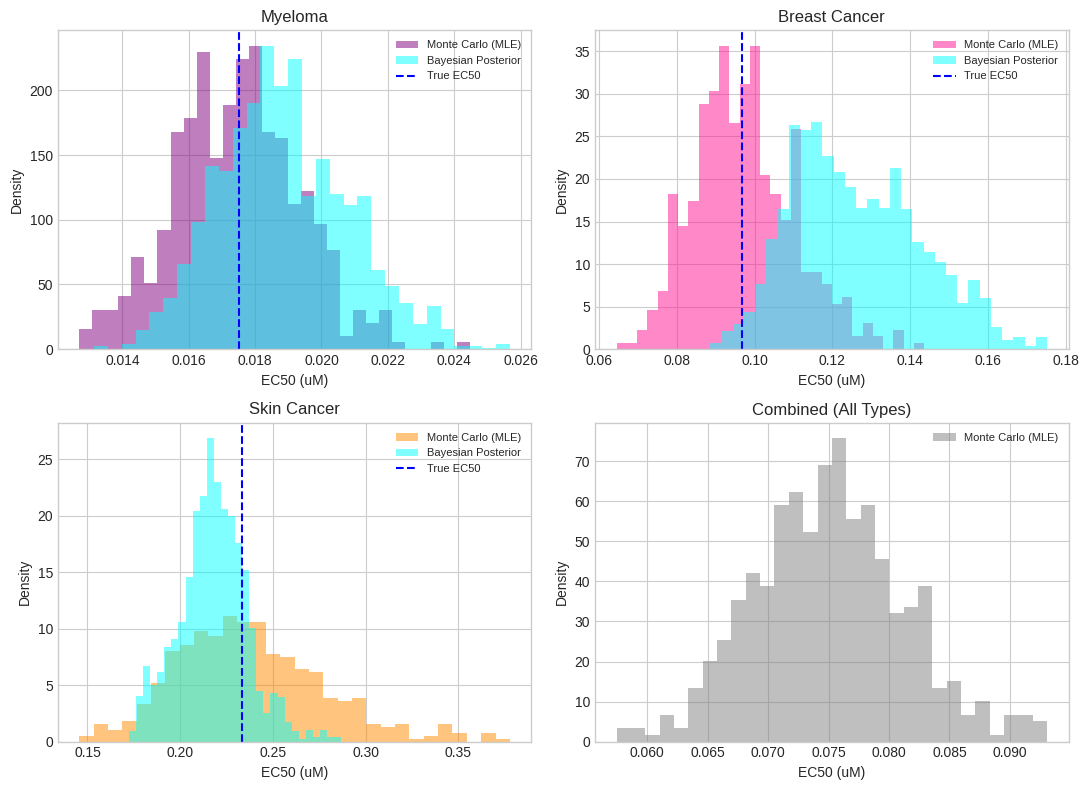

In [ ]:
import random
import math
import matplotlib.pyplot as plt

# Choosing a seed for reproducibility
random.seed(40)

# ============================================================
# 1. GENERATIVE MODEL & LIKELIHOOD
# ============================================================

def hill_model(concentration, ec50):
    return 1.0 / (1.0 + concentration / ec50)

def negative_log_likelihood(ec50, concentrations, observations, sigma):
    predicted = [hill_model(c, ec50) for c in concentrations]
    squared_error = sum((obs - pred)**2 for obs, pred in zip(observations, predicted))
    n = len(observations)
    return (0.5 * n * math.log(2 * math.pi * sigma**2)) + (squared_error / (2 * sigma**2))

# ============================================================
# 2. BAYESIAN THINKING (PRIOR, POSTERIOR & MCMC SAMPLER)
# ============================================================

def log_prior(ec50):
    """
    Bayesiansk Prior: Inkluderar biologisk förhandskunskap.
    EC50 måste vara positivt och högst troligt under 3.0 uM.
    """
    if ec50 <= 0 or ec50 > 3.0:
        return -float("inf")
    # Log-Normal prior centrerad kring 0.05 uM
    return -math.log(ec50) - ((math.log(ec50) - math.log(0.05))**2 / (2 * 1.0**2))

def log_posterior(ec50, concentrations, observations, sigma):
    """
    Posterior = Log-Prior + Log-Likelihood (vilket är -NLL)
    """
    lp = log_prior(ec50)
    if math.isinf(lp):
        return -float("inf")
    log_ll = -negative_log_likelihood(ec50, concentrations, observations, sigma)
    return lp + log_ll

def sample_bayes_mcmc(concentrations, observations, sigma, n_samples=3000, initial_ec50=0.1):
    """
    Metropolis-Hastings MCMC: Genererar sampel från posteriorfördelningen.
    """
    current_ec50 = initial_ec50
    samples = []

    for _ in range(n_samples):
        # Föreslå ett nytt EC50 i närheten med Gaussiskt kliv
        proposal = current_ec50 + random.gauss(0, 0.003)

        # Beräkna acceptanssannolikhet
        log_alpha = log_posterior(proposal, concentrations, observations, sigma) - log_posterior(current_ec50, concentrations, observations, sigma)

        if math.log(random.random()) < log_alpha:
            current_ec50 = proposal

        samples.append(current_ec50)

    # Ta bort "burn-in" (de första 1000 samplen innan kedjan stabiliserats)
    return samples[1000:]

# ============================================================
# 3. ADAPTIVE GRADIENT DESCENT OPTIMIZER (FREQUENTIST / MLE)
# ============================================================

def slope_at(score, theta, h=0.0001):
    return (score(theta + h) - score(theta - h)) / (2 * h)

def descend_adaptive(score, theta, alpha, h=0.0001, tol=1e-3, max_steps=1000):
    path = [theta]
    for step in range(max_steps):
        slope = slope_at(score, theta, h)
        if abs(slope) < tol:
            return path

        theta_try = theta - alpha * slope
        if theta_try <= 0:
            alpha = alpha * 0.5
            continue

        if score(theta_try) > score(theta):
            alpha = alpha * 0.5
        else:
            theta = theta_try
            alpha = alpha * 1.2

        path.append(theta)
    return path

def fit_ec50_adaptive(concentrations, observations, sigma, initial_ec50=0.5):
    score_func = lambda ec50: negative_log_likelihood(ec50, concentrations, observations, sigma)
    path = descend_adaptive(score_func, theta=initial_ec50, alpha=0.001)
    return path[-1]

# ============================================================
# DATA & PARAMETERS (Panobinostat S11)
# ============================================================

concentrations = [0.0025, 0.0080, 0.0250, 0.0800, 0.2500, 0.8000, 2.5300, 8.0000]

cancer_types = {
    "Myeloma": {"ec50_true": 0.0175, "sigma": 0.04, "color": "purple"},
    "Breast Cancer": {"ec50_true": 0.0969, "sigma": 0.05, "color": "pink"},
    "Skin Cancer": {"ec50_true": 0.2332, "sigma": 0.06, "color": "orange"}
}

# ============================================================
# 4. SINGLE EXPERIMENT SIMULATION
# ============================================================

simulated_data = {}
for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    obs_resp = [hill_model(c, ec50_true) + random.gauss(0, sig) for c in concentrations]
    simulated_data[c_type] = {"observed_response": obs_resp}

# Dataset för Variant 4: Kombinerat dataset
combined_concentrations = []
combined_observations = []
for c_type in cancer_types:
    combined_concentrations.extend(concentrations)
    combined_observations.extend(simulated_data[c_type]["observed_response"])

combined_sigma = sum(props["sigma"] for props in cancer_types.values()) / len(cancer_types)
combined_fitted_ec50 = fit_ec50_adaptive(combined_concentrations, combined_observations, combined_sigma)

# ============================================================
# 5. BAYESIAN POSTERIOR ANALYSIS ON SINGLE EXPERIMENTS
# ============================================================

print("\n=============================================================")
print(" BAYESIAN POSTERIOR ESTIMATES (SINGLE EXPERIMENT)")
print("=============================================================")
print(f"{'Cancer Type':<18} | {'True EC50':<10} | {'Posterior Mean':<14} | {'95% Credible Interval':<22}")
print("-" * 72)

bayes_samples = {}
for c_type, props in cancer_types.items():
    obs = simulated_data[c_type]["observed_response"]
    samples = sample_bayes_mcmc(concentrations, obs, props["sigma"], initial_ec50=props["ec50_true"])
    bayes_samples[c_type] = samples

    mean_p = sum(samples) / len(samples)
    sorted_s = sorted(samples)
    ci_low = sorted_s[int(0.025 * len(sorted_s))]
    ci_high = sorted_s[int(0.975 * len(sorted_s))]

    print(f"{c_type:<18} | {props['ec50_true']:<10.4f} | {mean_p:<14.4f} | [{ci_low:.4f}, {ci_high:.4f}]")

# ============================================================
# 6. MONTE CARLO SIMULATION (FREQUENTIST COMPARISON)
# ============================================================

n_simulations = 500
mc_results = {c: [] for c in cancer_types}
mc_results["Combined (All Types)"] = []

for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]
    for _ in range(n_simulations):
        sim_obs = [hill_model(c, ec50_true) + random.gauss(0, sig) for c in concentrations]
        est = fit_ec50_adaptive(concentrations, sim_obs, sig, initial_ec50=ec50_true)
        mc_results[c_type].append(est)

for _ in range(n_simulations):
    pooled_obs = []
    for c_type, props in cancer_types.items():
        pooled_obs.extend([hill_model(c, props["ec50_true"]) + random.gauss(0, props["sigma"]) for c in concentrations])
    est_c = fit_ec50_adaptive(combined_concentrations, pooled_obs, combined_sigma, initial_ec50=0.1)
    mc_results["Combined (All Types)"].append(est_c)

# ============================================================
# 7. VISUALIZE BAYESIAN POSTERIOR VS MONTE CARLO
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

all_variants = ["Myeloma", "Breast Cancer", "Skin Cancer", "Combined (All Types)"]
colors = ["purple", "deeppink", "darkorange", "gray"]

for idx, variant in enumerate(all_variants):
    ax = axes_list[idx]

    # Plotta Monte Carlo (Frequentist)
    ax.hist(mc_results[variant], bins=30, color=colors[idx], alpha=0.5, density=True, label="Monte Carlo (MLE)")

    # Om det är en av de enskilda cancertyperna, lägg över den Bayesianska posterior-fördelningen
    if variant in bayes_samples:
        ax.hist(bayes_samples[variant], bins=30, color="cyan", alpha=0.5, density=True, label="Bayesian Posterior")
        ax.axvline(cancer_types[variant]["ec50_true"], color="blue", linestyle="--", label="True EC50")

    ax.set_title(variant)
    ax.set_xlabel("EC50 (uM)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

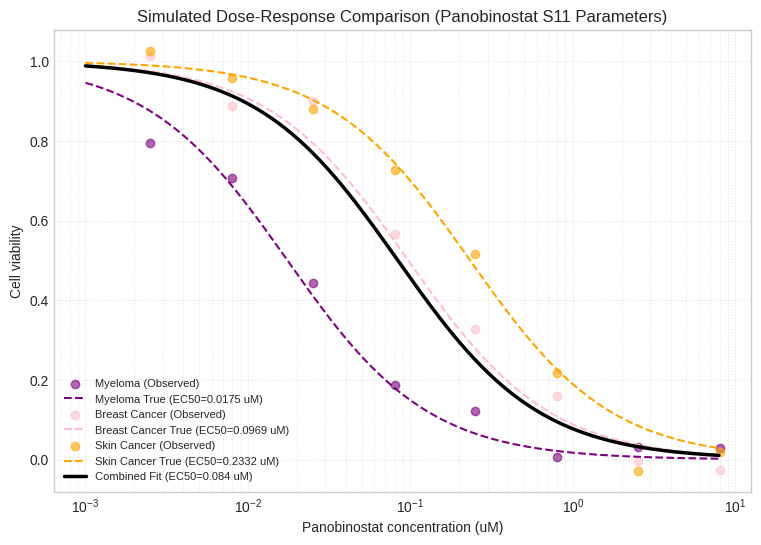


 BAYESIAN POSTERIOR ESTIMATES (SINGLE EXPERIMENT)
Cancer Type        | True EC50  | Posterior Mean | 95% Credible Interval 
------------------------------------------------------------------------
Myeloma            | 0.0175     | 0.0189         | [0.0154, 0.0232]
Breast Cancer      | 0.0969     | 0.1261         | [0.0998, 0.1595]
Skin Cancer        | 0.2332     | 0.2178         | [0.1810, 0.2557]


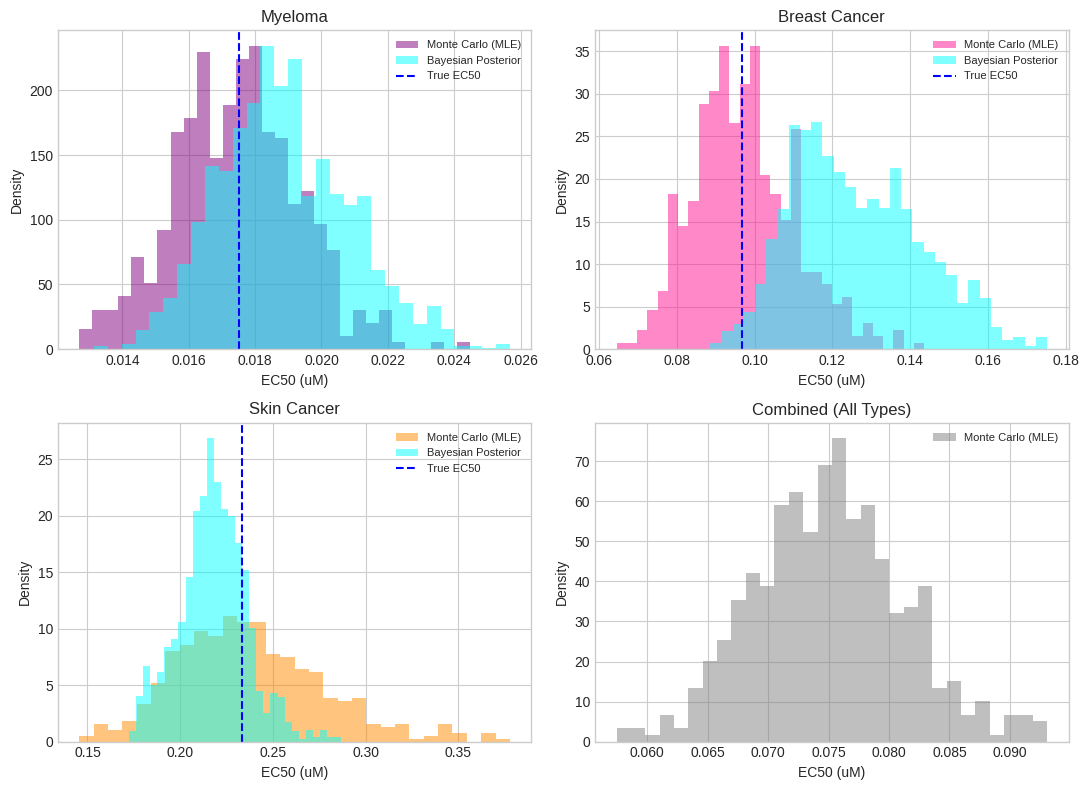

In [ ]:
import random
import math
import matplotlib.pyplot as plt

# Sätter seed för att göra Monte Carlo-simuleringen reproducerbar
random.seed(40)


# ============================================================
# STEG 1: DATAINSAMLING (EMPIRISK GRUND)
# Hämtar biologiska parametrar (EC50 och testade koncentrationer)
# för Panobinostat från CCLE (Tabell S11) för tre cancertyper.
# ============================================================

# Koncentrationer för Panobinostat (uM) från Tabell S11
concentrations = [0.0025, 0.0080, 0.0250, 0.0800, 0.2500, 0.8000, 2.5300, 8.0000]

# Empiriska genomsnittliga EC50-värden (uM) och mätosäkerhet (sigma)
cancer_types = {
    "Myeloma": {"ec50_true": 0.0175, "sigma": 0.04, "color": "purple"},
    "Breast Cancer": {"ec50_true": 0.0969, "sigma": 0.05, "color": "pink"},
    "Skin Cancer": {"ec50_true": 0.2332, "sigma": 0.06, "color": "orange"}
}


# ============================================================
# STEG 2: GENERATIV MODELLERING (HILL-EKVATIONEN)
# Beräknar den teoretiska, sanna överlevnaden för varje koncentration.
# ============================================================

def hill_model(concentration, ec50):
    """Förenklad Hill-ekvation för att modellera teoretisk överlevnadsgrad."""
    return 1.0 / (1.0 + concentration / ec50)


# ============================================================
# STEG 4: PARAMETERANPASSNING (NLL & ADAPTIV GRADIENT DESCENT)
# Formulerar NLL och söker upp det EC50-värde som bäst passar data.
# ============================================================

def negative_log_likelihood(ec50, concentrations, observations, sigma):
    """Beräknar Negative Log-Likelihood (NLL) för Gaussiskt mätbrus."""
    predicted = [hill_model(c, ec50) for c in concentrations]
    squared_error = sum((obs - pred) ** 2 for obs, pred in zip(observations, predicted))
    n = len(observations)
    return (0.5 * n * math.log(2 * math.pi * sigma**2)) + (squared_error / (2 * sigma**2))


def slope_at(score, theta, h=0.0001):
    """Beräknar den numeriska derivatan för NLL vid ett visst EC50."""
    return (score(theta + h) - score(theta - h)) / (2 * h)


def descend_adaptive(score, theta, alpha, h=0.0001, tol=1e-3, max_steps=1000):
    """Söker minimat för NLL med adaptiv steglängd."""
    path = [theta]
    for step in range(max_steps):
        slope = slope_at(score, theta, h)
        if abs(slope) < tol:
            return path

        theta_try = theta - alpha * slope
        if theta_try <= 0:
            alpha = alpha * 0.5
            continue

        if score(theta_try) > score(theta):
            alpha = alpha * 0.5
        else:
            theta = theta_try
            alpha = alpha * 1.2

        path.append(theta)
    return path


def fit_ec50_adaptive(concentrations, observations, sigma, initial_ec50=0.5):
    """Använder adaptiv gradient descent för att hitta Maximum Likelihood Estimator (MLE)."""
    score_func = lambda ec50: negative_log_likelihood(ec50, concentrations, observations, sigma)
    path = descend_adaptive(score_func, theta=initial_ec50, alpha=0.001)
    return path[-1]


# ============================================================
# STEG 5A: OSÄKERHETSANALYS – BAYESIANSK INFERENS (PRIOR & MCMC)
# Kombinerar biologisk förhandskunskap med likelihood för ett enskilt experiment.
# ============================================================

def log_prior(ec50):
    """
    Bayesiansk Prior: Inkluderar biologisk förhandskunskap.
    EC50 måste vara positivt och högst troligt under 3.0 uM.
    """
    if ec50 <= 0 or ec50 > 3.0:
        return -float("inf")
    # Log-Normal prior centrerad kring 0.05 uM
    return -math.log(ec50) - ((math.log(ec50) - math.log(0.05)) ** 2 / (2 * 1.0 ** 2))


def log_posterior(ec50, concentrations, observations, sigma):
    """Posterior = Log-Prior + Log-Likelihood (vilket är -NLL)"""
    lp = log_prior(ec50)
    if math.isinf(lp):
        return -float("inf")
    log_ll = -negative_log_likelihood(ec50, concentrations, observations, sigma)
    return lp + log_ll


def sample_bayes_mcmc(concentrations, observations, sigma, n_samples=3000, initial_ec50=0.1):
    """Metropolis-Hastings MCMC: Genererar sampel från posteriorfördelningen."""
    current_ec50 = initial_ec50
    samples = []

    for _ in range(n_samples):
        # Föreslå ett nytt EC50 i närheten med Gaussiskt kliv
        proposal = current_ec50 + random.gauss(0, 0.003)

        # Beräkna acceptanssannolikhet
        log_alpha = log_posterior(proposal, concentrations, observations, sigma) - log_posterior(current_ec50, concentrations, observations, sigma)

        if math.log(random.random()) < log_alpha:
            current_ec50 = proposal

        samples.append(current_ec50)

    # Ta bort "burn-in" (de första 1000 samplen)
    return samples[1000:]


# ============================================================
# STEG 3 & 7: BRUSMODELLERING & JÄMFÖRANDE ANALYS (HETEROGENITET)
# Genererar enstaka experiment med mätbrus (Steg 3) samt slår ihop
# datasetet (Variant 4) för att analysera heterogenitet (Steg 7).
# ============================================================

simulated_data = {}
for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]

    # STEG 3: Lägger på normalfördelat mätbrus (sigma) på teoretiska värden
    obs_resp = [hill_model(c, ec50_true) + random.gauss(0, sig) for c in concentrations]
    simulated_data[c_type] = {"observed_response": obs_resp}

# STEG 7: Slår ihop data från alla 3 cancertyper (Variant 4 - Kombinerat dataset)
combined_concentrations = []
combined_observations = []
for c_type in cancer_types:
    combined_concentrations.extend(concentrations)
    combined_observations.extend(simulated_data[c_type]["observed_response"])

combined_sigma = sum(props["sigma"] for props in cancer_types.values()) / len(cancer_types)
combined_fitted_ec50 = fit_ec50_adaptive(combined_concentrations, combined_observations, combined_sigma)


# ============================================================
# VISUALISERING 1: DOS-RESPONS-KURVOR (SINGLE EXPERIMENT)
# Visar hur sammanslagningen (Variant 4) tappar biologisk precision.
# ============================================================

plt.figure(figsize=(9, 6))

fine_concentrations = []
curr = 0.001
while curr <= 8.0:
    fine_concentrations.append(curr)
    curr *= 1.05

for c_type, props in cancer_types.items():
    plt.scatter(
        concentrations,
        simulated_data[c_type]["observed_response"],
        color=props["color"],
        alpha=0.6,
        label=f"{c_type} (Observed)"
    )

    fine_curve = [hill_model(c, props["ec50_true"]) for c in fine_concentrations]
    plt.plot(
        fine_concentrations,
        fine_curve,
        color=props["color"],
        linestyle="--",
        label=f"{c_type} True (EC50={props['ec50_true']} uM)"
    )

# Visualiserar den missvisande gemensamma anpassningen (Steg 7)
combined_fitted_curve = [hill_model(c, combined_fitted_ec50) for c in fine_concentrations]
plt.plot(
    fine_concentrations,
    combined_fitted_curve,
    color="black",
    linewidth=2.5,
    linestyle="-",
    label=f"Combined Fit (EC50={combined_fitted_ec50:.3f} uM)"
)

plt.xscale("log")
plt.xlabel("Panobinostat concentration (uM)")
plt.ylabel("Cell viability")
plt.title("Simulated Dose-Response Comparison (Panobinostat S11 Parameters)")
plt.legend(fontsize=8, loc="lower left")
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()


# ============================================================
# KÖRNING: STEG 5A (BAYESIANSK ANALYS PÅ ENSTAKA EXPERIMENT)
# ============================================================

print("\n=============================================================")
print(" BAYESIAN POSTERIOR ESTIMATES (SINGLE EXPERIMENT)")
print("=============================================================")
print(f"{'Cancer Type':<18} | {'True EC50':<10} | {'Posterior Mean':<14} | {'95% Credible Interval':<22}")
print("-" * 72)

bayes_samples = {}
for c_type, props in cancer_types.items():
    obs = simulated_data[c_type]["observed_response"]
    samples = sample_bayes_mcmc(concentrations, obs, props["sigma"], initial_ec50=props["ec50_true"])
    bayes_samples[c_type] = samples

    mean_p = sum(samples) / len(samples)
    sorted_s = sorted(samples)
    ci_low = sorted_s[int(0.025 * len(sorted_s))]
    ci_high = sorted_s[int(0.975 * len(sorted_s))]

    print(f"{c_type:<18} | {props['ec50_true']:<10.4f} | {mean_p:<14.4f} | [{ci_low:.4f}, {ci_high:.4f}]")


# ============================================================
# STEG 5B: OSÄKERHETSANALYS – MONTE CARLO-SIMULERING
# Upprepar experimentet 500 gånger för att studera spridningen i EC50.
# ============================================================

n_simulations = 500
mc_results = {c: [] for c in cancer_types}
mc_results["Combined (All Types)"] = []

# A. Monte Carlo för de 3 enskilda cancertyperna
for c_type, props in cancer_types.items():
    ec50_true = props["ec50_true"]
    sig = props["sigma"]
    for _ in range(n_simulations):
        sim_obs = [hill_model(c, ec50_true) + random.gauss(0, sig) for c in concentrations]
        est = fit_ec50_adaptive(concentrations, sim_obs, sig, initial_ec50=ec50_true)
        mc_results[c_type].append(est)

# B. Monte Carlo för Variant 4: Kombinerat dataset (Steg 7)
for _ in range(n_simulations):
    pooled_obs = []
    for c_type, props in cancer_types.items():
        pooled_obs.extend([hill_model(c, props["ec50_true"]) + random.gauss(0, props["sigma"]) for c in concentrations])
    est_c = fit_ec50_adaptive(combined_concentrations, pooled_obs, combined_sigma, initial_ec50=0.1)
    mc_results["Combined (All Types)"].append(est_c)


# ============================================================
# VISUALISERING 2: HISTOGRAM (BAYES POSTERIOR VS MONTE CARLO)
# Jämför spridningen mellan metoder samt påvisar heterogenitetseffekten.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

all_variants = ["Myeloma", "Breast Cancer", "Skin Cancer", "Combined (All Types)"]
colors = ["purple", "deeppink", "darkorange", "gray"]

for idx, variant in enumerate(all_variants):
    ax = axes_list[idx]

    # Plotta Monte Carlo (MLE via Gradient Descent)
    ax.hist(mc_results[variant], bins=30, color=colors[idx], alpha=0.5, density=True, label="Monte Carlo (MLE)")

    # Plotta Bayesiansk Posterior för enskilda cancertyper
    if variant in bayes_samples:
        ax.hist(bayes_samples[variant], bins=30, color="cyan", alpha=0.5, density=True, label="Bayesian Posterior")
        ax.axvline(cancer_types[variant]["ec50_true"], color="blue", linestyle="--", label="True EC50")

    ax.set_title(variant)
    ax.set_xlabel("EC50 (uM)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()